In [1]:
# Install Kaggle API :
!pip install -q kaggle

In [2]:
# Setting Kaggle Credentials :
import os
os.environ['KAGGLE_USERNAME'] = 'dhruvbhagchandani19'  # Replace with your Kaggle username
os.environ['KAGGLE_KEY'] = 'KGAT_5cccbdc83e00bb08a35f6e2c9378bb1b'  # Replace with your Kaggle API key

In [3]:
# Downloading the dataset :
!kaggle datasets download -d raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables

Dataset URL: https://www.kaggle.com/datasets/raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables
License(s): CC0-1.0
fresh-and-stale-images-of-fruits-and-vegetables.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
# unzip the dataset :
!unzip -q fresh-and-stale-images-of-fruits-and-vegetables.zip -d ./fruitveg_dataset

replace ./fruitveg_dataset/ImageLabels.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
# importing required libraries :
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

In [6]:
print("\n" + "="*60)
print("DATASET STRUCTURE")
print("="*60)


DATASET STRUCTURE


In [7]:
dataset_path = './fruitveg_dataset'
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    sub_indent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show only first 5 files in each directory
        print(f'{sub_indent}{file}')
    if len(files) > 5:
        print(f'{sub_indent}... and {len(files) - 5} more files')

print("\n" + "="*60)
print("DATASET LOADED SUCCESSFULLY!")
print("="*60)

fruitveg_dataset/
  ImageLabels.txt
  stale_capsicum/
    WhatsApp Image 2020-11-07 at 11.43.16 PM.jpeg_0_5624.jpg
    WhatsApp Image 2020-11-07 at 11.43.17 PM.jpeg_0_9391.jpg
    WhatsApp Image 2020-11-07 at 11.35.36 PM(1).jpeg_0_1524.jpg
    WhatsApp Image 2020-11-07 at 11.35.37 PM.jpeg_0_4838.jpg
    WhatsApp Image 2020-11-07 at 11.35.36 PM.jpeg_0_7375.jpg
    ... and 896 more files
  fresh_orange/
    rotated_by_45_Screen Shot 2018-06-12 at 11.50.28 PM.png
    rotated_by_30_Screen Shot 2018-06-13 at 12.02.05 AM.png
    vertical_flip_Screen Shot 2018-06-13 at 12.06.43 AM.png
    rotated_by_45_Screen Shot 2018-06-13 at 12.11.10 AM.png
    rotated_by_30_Screen Shot 2018-06-13 at 12.14.18 AM.png
    ... and 1461 more files
  fresh_tomato/
    DSCN4158.jpg_0_8250.jpg
    DSCN4101.jpg_0_3137.jpg
    tomato1_30.jpg_0_6876.jpg
    DSCN4070.jpg_0_5447.jpg
    DSCN4070.jpg_0_6492.jpg
    ... and 976 more files
  fresh_bitter_gourd/
    IMG_20200823_131855.jpg_0_2690.jpg
    IMG_20200823_1318

EXPLORATORY DATA ANALYSIS :

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [9]:
dataset_path = './fruitveg_dataset'

In [10]:
# Get class distribution
class_counts = {}

for root, dirs, files in os.walk(dataset_path):
    if len(files) > 0:
        class_name = os.path.basename(root)
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
        if image_files:
            class_counts[class_name] = len(image_files)

In [11]:
# Display counts
print("Class Distribution:")
print("-" * 50)
for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count} images")

Class Distribution:
--------------------------------------------------
fresh_apple: 1693 images
fresh_banana: 1581 images
fresh_bitter_gourd: 327 images
fresh_capsicum: 990 images
fresh_orange: 1466 images
fresh_tomato: 981 images
stale_apple: 2342 images
stale_banana: 1467 images
stale_bitter_gourd: 357 images
stale_capsicum: 901 images
stale_orange: 1595 images
stale_tomato: 982 images


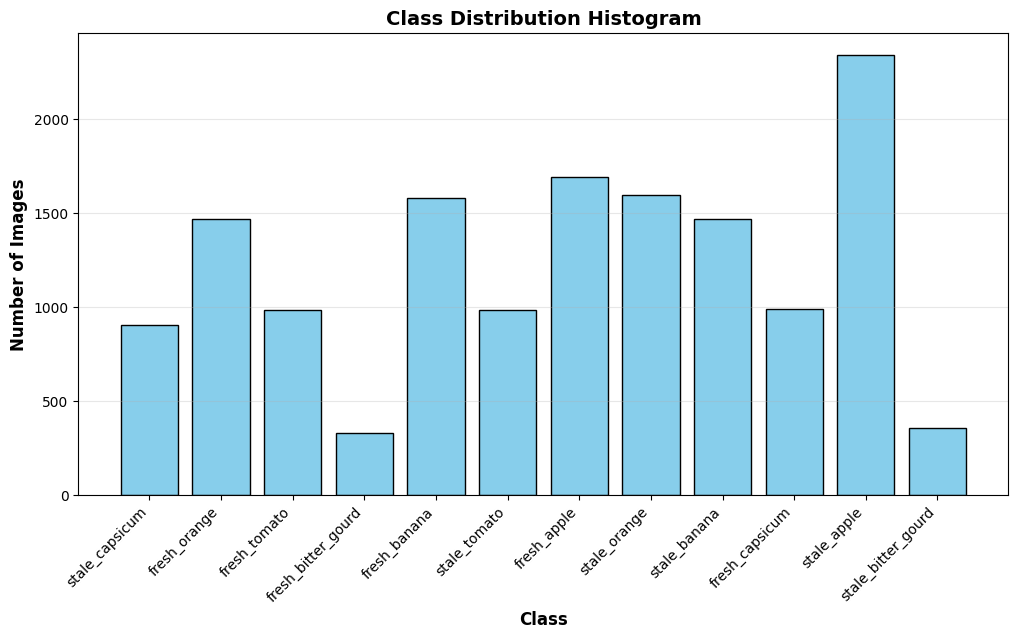

In [12]:
# Plot histogram
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue', edgecolor='black')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
plt.title('Class Distribution Histogram', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

In [13]:
# importing required libraries :
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

In [14]:
# Image parameters
IMG_HEIGHT = 224  # Standard size for most CNNs (ResNet, VGG, etc.)
IMG_WIDTH = 224
IMG_CHANNELS = 3

In [15]:
# Training parameters
TEST_SIZE = 0.2
VAL_SIZE = 0.15  # 15% of training data for validation
RANDOM_STATE = 42
BATCH_SIZE = 32

In [16]:
# load dataset function :
def load_dataset(dataset_path):
    """Load all images and labels from dataset"""
    images = []
    labels = []
    class_names = []

    # Get all class directories
    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)

        if os.path.isdir(class_path):
            class_names.append(class_name)
            print(f"\nLoading class: {class_name}")

            image_files = [f for f in os.listdir(class_path)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

            for idx, img_file in enumerate(image_files):
                img_path = os.path.join(class_path, img_file)

                try:
                    # Load image
                    img = cv2.imread(img_path)
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                    # Resize image
                    img_resized = cv2.resize(img_rgb, (IMG_WIDTH, IMG_HEIGHT))

                    images.append(img_resized)
                    labels.append(class_name)

                    if (idx + 1) % 500 == 0:
                        print(f"  Loaded {idx + 1}/{len(image_files)} images")

                except Exception as e:
                    print(f"  Error loading {img_file}: {e}")
                    continue

            print(f"Loaded {len([l for l in labels if l == class_name])} images from {class_name}")

    return np.array(images), np.array(labels), class_names

In [17]:
# load all data :
X, y, class_names = load_dataset(dataset_path)


Loading class: fresh_apple
  Loaded 500/1693 images
  Loaded 1000/1693 images
  Loaded 1500/1693 images
Loaded 1693 images from fresh_apple

Loading class: fresh_banana
  Loaded 500/1581 images
  Loaded 1000/1581 images
  Loaded 1500/1581 images
Loaded 1581 images from fresh_banana

Loading class: fresh_bitter_gourd
Loaded 327 images from fresh_bitter_gourd

Loading class: fresh_capsicum
  Loaded 500/990 images
Loaded 990 images from fresh_capsicum

Loading class: fresh_orange
  Loaded 500/1466 images
  Loaded 1000/1466 images
Loaded 1466 images from fresh_orange

Loading class: fresh_tomato
  Loaded 500/981 images
Loaded 981 images from fresh_tomato

Loading class: stale_apple
  Loaded 500/2342 images
  Loaded 1000/2342 images
  Loaded 1500/2342 images
  Loaded 2000/2342 images
Loaded 2342 images from stale_apple

Loading class: stale_banana
  Loaded 500/1467 images
  Loaded 1000/1467 images
Loaded 1467 images from stale_banana

Loading class: stale_bitter_gourd
Loaded 357 images fro

In [18]:
# encode labels :

# Create label mapping
label_mapping = {class_name: idx for idx, class_name in enumerate(class_names)}
print("\nLabel Mapping:")
for class_name, idx in label_mapping.items():
    print(f"  {class_name} → {idx}")

# Convert labels to integers
y_encoded = np.array([label_mapping[label] for label in y])

# One-hot encode labels
y_categorical = to_categorical(y_encoded, num_classes=len(class_names))


Label Mapping:
  fresh_apple → 0
  fresh_banana → 1
  fresh_bitter_gourd → 2
  fresh_capsicum → 3
  fresh_orange → 4
  fresh_tomato → 5
  stale_apple → 6
  stale_banana → 7
  stale_bitter_gourd → 8
  stale_capsicum → 9
  stale_orange → 10
  stale_tomato → 11


In [19]:
X_normalized = X

In [20]:
# train, test, val split :

X_train_val, X_test, y_train_val, y_test, y_train_val_labels, y_test_labels = train_test_split(
    X_normalized, y_categorical, y_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

# Split: Train vs Val
X_train, X_val, y_train, y_val, y_train_labels, y_val_labels = train_test_split(
    X_train_val, y_train_val, y_train_val_labels,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_val_labels
)

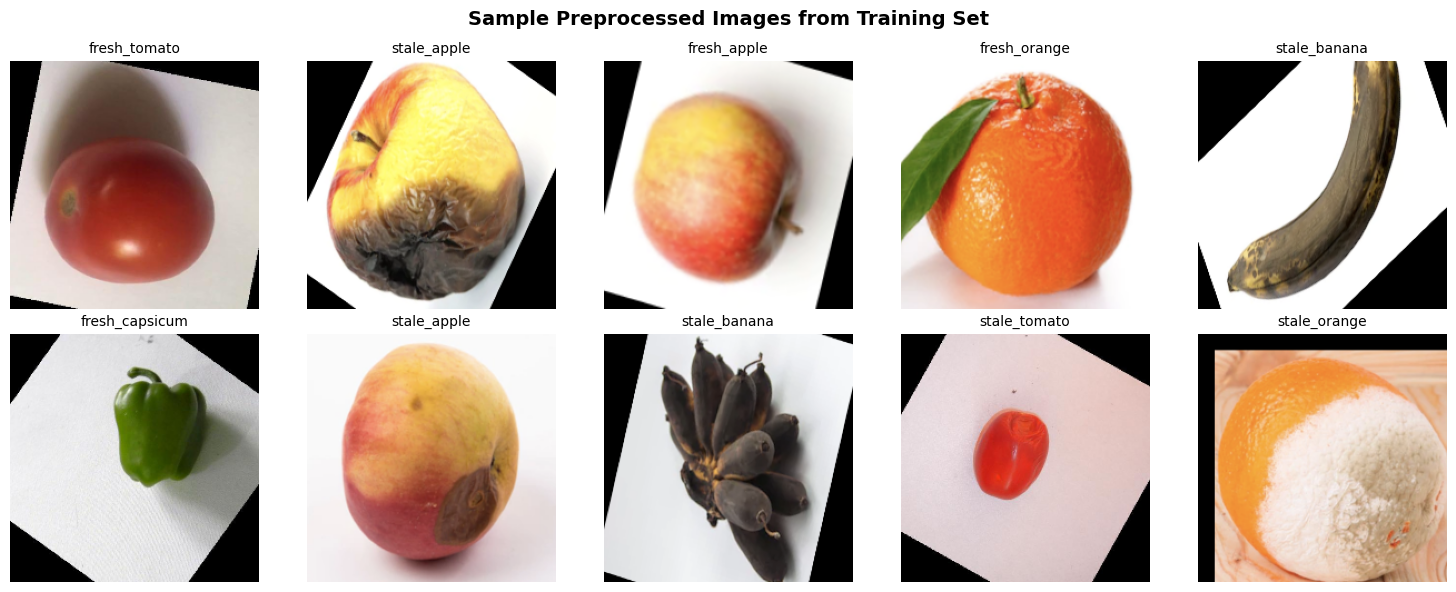

In [21]:
# verifying preprocessing with plots :
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Preprocessed Images from Training Set', fontsize=14, fontweight='bold')

for i in range(10):
    row = i // 5
    col = i % 5

    # Get random image
    idx = np.random.randint(0, len(X_train))

    axes[row, col].imshow(X_train[idx])
    axes[row, col].set_title(f"{class_names[y_train_labels[idx]]}", fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('preprocessed_samples.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# save all preprocessed data :
# Save as numpy arrays
np.save('X_train.npy', X_train)
np.save('X_val.npy', X_val)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_val.npy', y_val)
np.save('y_test.npy', y_test)

# Save class names
np.save('class_names.npy', class_names)

# Save label mapping
import json
with open('label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=4)

In [23]:
# CNN Architecture :
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_model(num_classes):
    # 1. Load the Pre-trained Base Model (MobileNetV2)
    # include_top=False removes the final classification layer so we can add our own
    # weights='imagenet' uses the learned patterns from millions of images
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # 2. Freeze the Base Model
    # We don't want to retrain these layers yet; they are already good feature extractors.
    base_model.trainable = False

    # 3. Add Custom Classification Head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)      # Condense feature map to a vector
    x = Dense(128, activation='relu')(x) # Dense layer to learn specific fruit features
    x = Dropout(0.5)(x)                  # Dropout to prevent overfitting

    # Final Output Layer (Softmax for probability distribution across classes)
    predictions = Dense(num_classes, activation='softmax')(x)

    # 4. Create the Final Model
    model = Model(inputs=base_model.input, outputs=predictions)

    # 5. Compile the Model
    model.compile(
        optimizer=Adam(learning_rate=0.0001), # Lower learning rate for fine-tuning
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Initialize the model
# Based on your EDA, you have 12 classes (fresh/stale * 6 types)
model = build_model(num_classes=len(class_names))

# Verify the structure
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,500 (9.24 MB)

 Trainable params: 165,516 (646.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
import tensorflow as tf
import gc

# 1. Clear Memory first
tf.keras.backend.clear_session()
gc.collect()

# 2. Reduced Parameters
BATCH_SIZE = 16  # Reduced from 32 to 16 to save GPU/RAM memory
IMG_SIZE = (224, 224)
DATA_DIR = './fruitveg_dataset' # Ensure this matches your path

# 3. Create Datasets WITHOUT .cache()
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Preprocessing function (MobileNetV2 style)
def preprocess(image, label):
    return tf.keras.applications.mobilenet_v2.preprocess_input(image), label

# 4. Pipeline Optimization (NO .cache() here!)
# We only use prefetch, which buffers just a few batches, not the whole dataset.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(preprocess).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(preprocess).prefetch(buffer_size=AUTOTUNE)

print("Memory-safe pipelines created.")

# 5. Re-build and Compile Model (Since we cleared session)
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
predictions = tf.keras.layers.Dense(12, activation='softmax')(x) # 12 classes

model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('best_fruit_model.keras', save_best_only=True)
    ],
    verbose=1
)

Found 14682 files belonging to 12 classes.
Using 11746 files for training.
Found 14682 files belonging to 12 classes.
Using 2936 files for validation.
Memory-safe pipelines created.
Epoch 1/5
735/735 ━━━━━━━━━━━━━━━━━━━━ 311s 418ms/step - accuracy: 0.5916 - loss: 1.2953 - val_accuracy: 0.9673 - val_loss: 0.1494
Epoch 2/5
735/735 ━━━━━━━━━━━━━━━━━━━━ 307s 418ms/step - accuracy: 0.9321 - loss: 0.2341 - val_accuracy: 0.9813 - val_loss: 0.0841
Epoch 3/5
735/735 ━━━━━━━━━━━━━━━━━━━━ 324s 440ms/step - accuracy: 0.9615 - loss: 0.1404 - val_accuracy: 0.9867 - val_loss: 0.0620
Epoch 4/5
735/735 ━━━━━━━━━━━━━━━━━━━━ 312s 425ms/step - accuracy: 0.9720 - loss: 0.0975 - val_accuracy: 0.9888 - val_loss: 0.0490
Epoch 5/5
735/735 ━━━━━━━━━━━━━━━━━━━━ 335s 455ms/step - accuracy: 0.9782 - loss: 0.0783 - val_accuracy: 0.9894 - val_loss: 0.0419


Testing on image: ./fruitveg_dataset/stale_apple/vertical_flip_Screen Shot 2018-06-08 at 2.47.54 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step


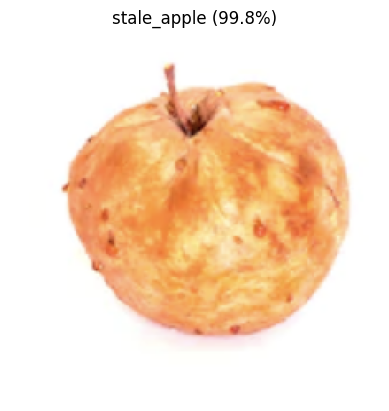


--- QUALITY SCORE: 1/5 ---


In [25]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Define your dataset path
DATA_DIR = './fruitveg_dataset'

# 2. Automatically pick a random image
def get_random_image_path(base_path):
    # Get all class folders
    classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

    # Pick a random class
    random_class = random.choice(classes)
    class_path = os.path.join(base_path, random_class)

    # Pick a random file from that class
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not files:
        return None
    random_file = random.choice(files)

    return os.path.join(class_path, random_file)

# Get a real existing path
test_image_path = get_random_image_path(DATA_DIR)
print(f"Testing on image: {test_image_path}")

# 3. Predict Function
def predict_and_score(image_path, model, class_names):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    # Preprocess
    img_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(img_batch)

    # Predict
    predictions = model.predict(img_preprocessed)
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = np.max(predictions) * 100

    # Display
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence:.1f}%)")
    plt.show()

    return predicted_class

# 4. Run it
if test_image_path:
    # Get class names again just in case
    # We are getting class_names from the global scope, which should be correct after training.
    # However, if this cell is run independently, it might be good to re-load them.
    # For this specific execution flow, the `class_names` variable from previous cells is available.
    label = predict_and_score(test_image_path, model, class_names)

    # 5. Quality Score Logic
    score = 3
    if "fresh" in label.lower():
        score = 5
    elif "stale" in label.lower():
        score = 1

    print(f"\n--- QUALITY SCORE: {score}/5 ---")
else:
    print("Could not find any images in the dataset folder.")

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Evaluate Model Accuracy
print("Evaluating model on Test/Validation data...")
loss, accuracy = model.evaluate(val_ds, verbose=1)

print(f"\n--------------------------------------")
print(f" FINAL TEST ACCURACY: {accuracy * 100:.2f}%")
print(f" FINAL TEST LOSS:     {loss:.4f}")
print(f"--------------------------------------")

Evaluating model on Test/Validation data...
184/184 ━━━━━━━━━━━━━━━━━━━━ 62s 337ms/step - accuracy: 0.9895 - loss: 0.0369

--------------------------------------
 FINAL TEST ACCURACY: 98.94%
 FINAL TEST LOSS:     0.0419
--------------------------------------


In [28]:
from google.colab import files

# Save the model locally in the Colab environment first
model.save('final_fruit_model.keras')

# Trigger the browser download
files.download('final_fruit_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>